In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import great_tables
from great_tables import GT, md, html


In [17]:
data =  pd.read_excel(r"Numex_preliminar_base.xlsx")#Results_isofys\test.xlsx")#
data = data.drop(columns = ["Unnamed: 0"])
description = data.groupby(['name', 'Sub']).agg(["mean","std"]).reset_index()

description.columns = ['_'.join(col).strip('_') for col in description.columns.values]



C:\Users\selene.baez\AppData\Local\Temp\ipykernel_18696\1962797711.py:3: FutureWarning: ['genus', 'specie', 'Site', '[C]%'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  description = data.groupby(['name', 'Sub']).agg(["mean","std"]).reset_index()


In [20]:
# Create a great table
gt_table = (
    GT(description)
    .fmt_number(columns=[col for col in description.columns if 'mean' in col or 'std' in col], decimals=2)
    .tab_header(
        title="Descriptive Statistics by Name and Sub",
        subtitle="Mean and standard deviation for each group"
    )
    .opt_stylize()  # use default styling
)

# View in Jupyter / notebook
gt_table

GT(_tbl_data=                       name Sub  Plot_mean  Plot_std   TreeID_mean  \
0       Alchornea lojaensis   C   8.333333  6.555128   3582.000000   
1       Alchornea lojaensis   N   8.500000  5.582711   2025.100000   
2       Alchornea lojaensis  NP   8.250000  5.365232   3196.875000   
3       Alchornea lojaensis   P   7.500000  5.006662   2781.500000   
4        Clarisia  racemosa   C  11.333333  3.055050   2372.333333   
5        Clarisia  racemosa   N   7.000000       NaN   4997.000000   
6        Clarisia  racemosa  NP   9.750000  4.573474   5696.750000   
7        Clarisia  racemosa   P   7.750000  3.500000   4672.500000   
8   Hedyosmun  purpurascens   C   8.800000  5.718391  19011.000000   
9   Hedyosmun  purpurascens   N  11.666667  3.723797  10278.166667   
10  Hedyosmun  purpurascens  NP  10.333333  6.027714  15657.333333   
11  Hedyosmun  purpurascens   P   8.714286  4.889250  19010.571429   
12            Myrcia sp nov   C   8.000000  6.210590   3185.933333   
13            Myrcia sp nov   N   9.100000  6.384878   4482.800000   
14            Myrcia sp nov  NP  11.076923  6.034091   2562.230769   
15            Myrcia sp nov   P   9.916667  5.615860   3726.916667   
16           Pouteria torta   C   8.000000  2.529822   3350.545455   
17           Pouteria torta   N  10.300000  5.121849   3384.200000   
18           Pouteria torta  NP   4.571429  5.349677   3783.428571   
19           Pouteria torta   P   6.375000  4.274091   5592.125000   
20      Weinmania  loxensis   C   4.400000  3.714835   3062.800000   
21      Weinmania  loxensis   N   5.800000  3.563706   4285.200000   
22      Weinmania  loxensis  NP   9.500000  2.121320   1221.000000   
23      Weinmania  loxensis   P   7.500000  3.674235   4276.333333   

     TreeID_std  [C_b]%_mean  [C_b]%_std  bulk_δ13C (‰ v.s.V-PDB)_mean  \
0   3605.839935     0.489936    0.009186                    -29.082980   
1   2884.995531     0.487685    0.010078                    -29.236311   
2   3409.204660     0.481323    0.027854                    -29.452430   
3   3491.052411     0.485182    0.008200                    -29.313753   
4    566.613037     0.421372    0.014358                    -32.223184   
5           NaN     0.447145         NaN                    -32.984314   
6   2421.465448     0.430497    0.014051                    -32.119318   
7   3178.606036     0.438345    0.012741                    -31.553456   
8      6.595453     0.438017    0.006141                    -28.682767   
9   9564.150635     0.434849    0.010105                    -27.776059   
10  5816.516340     0.442684    0.006625                    -26.988340   
11     5.061526     0.436699    0.005987                    -29.220924   
12  3627.110981     0.472365    0.009436                    -31.274239   
13  3840.281002     0.470863    0.006788                    -30.865576   
14  3389.360637     0.464637    0.006034                    -30.623040   
15  3890.402677     0.469878    0.009986                    -30.784394   
16  2417.424967     0.480480    0.028379                    -33.830144   
17  2373.629232     0.476522    0.013879                    -33.196263   
18  2991.260652     0.477948    0.005164                    -33.982207   
19  3056.461139     0.479212    0.005509                    -33.567226   
20  2546.878815     0.444078    0.007834                    -29.147029   
21  4243.312704     0.445457    0.014196                    -29.300978   
22   152.735065     0.460098    0.009125                    -30.077729   
23  3354.676239     0.440546    0.011173                    -29.472586   

    bulk_δ13C (‰ v.s.V-PDB)_std  ...  area_basal_m2_mean  area_basal_m2_std  \
0                      0.817164  ...                 NaN                NaN   
1                      1.067009  ...                 NaN                NaN   
2                      1.507435  ...                 NaN                NaN   
3                      1.131405  ...                 NaN             

In [ ]:
import calculate_iWUE
%run calculate_iWUE.py


In [ ]:
data = calculate_iWUE(data)
data

No Delete [C] m/m (%) values lower than 35%
No Cleaning negative values of iWUE (μmol/mol)
The length of the df is 183


,Plot,TreeID,Sub,name,genus,specie,Site,[C_b]%,bulk_δ13C (‰ v.s.V-PDB),[N],...,SLA (cm²/g),area_basal_m2,P,N_P,SLA,code,t13C_cell,Ci,Ci/Ca,iWUE (μmol/mol)
0,1,1608,C,Weinmania loxensis,Weinmania,loxensis,CaNu,0.448019,-29.445403,0.011318,...,71.478774,0.012768,NaN,NaN,NaN,NaN,19.113177,296.697099,0.701222,79.010707
1,1,2108,NP,Pouteria torta,Pouteria,torta,BoN,0.474799,-35.494058,0.018562,...,96.280797,0.012548,NaN,NaN,NaN,NaN,25.186293,410.397182,0.969944,7.948155
2,1,5861,C,Weinmania loxensis,Weinmania,loxensis,CaNu,0.453564,-29.504389,0.010674,...,73.138889,0.008268,NaN,NaN,NaN,NaN,19.553575,304.942179,0.720709,73.857532
3,1,7887,NP,Pouteria torta,Pouteria,torta,BoN,0.470359,-33.277958,0.015958,...,69.130096,0.190117,NaN,NaN,NaN,NaN,22.815944,366.019830,0.865061,35.684000
4,1,8423,NP,Pouteria torta,Pouteria,torta,BoN,0.479109,-35.153026,0.016258,...,82.405939,0.017180,NaN,NaN,NaN,NaN,24.656245,400.473700,0.946491,14.150331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,4,188,NP,Alchornea lojaensis,Alchornea,lojaensis,SFNu,0.473038,-29.872922,0.010573,...,NaN,NaN,NaN,NaN,NaN,592091.0,19.238966,299.052110,0.706788,77.538825
178,14,685,NP,Myrcia sp nov,Myrcia,sp nov,SFNu,0.462155,-30.825714,0.010495,...,NaN,NaN,NaN,NaN,NaN,592302.0,18.767416,290.223818,0.685923,83.056507
179,13,627,N,Myrcia sp nov,Myrcia,sp nov,SFNu,0.472064,-30.300706,0.008710,...,NaN,NaN,NaN,NaN,NaN,592272.0,17.940639,274.745004,0.649340,92.730766
180,1,9091,C,Alchornea lojaensis,Alchornea,lojaensis,SFNu,0.499427,-29.629863,0.012680,...,NaN,NaN,NaN,NaN,NaN,592029.0,18.735995,289.635556,0.684533,83.424171


In [ ]:
#add aditional data
#information sent by Alejandra
def add_site_info(df):
    def fill_info(row):
        if row['Site'] == 'CaNu ':
            row['annual_precipitation_mm'] = 4500
            row['elevation_m'] = 3000
            row['mean_annual_temperature_C'] = 10
        elif row['Site'] == 'BoN':
            row['annual_precipitation_mm'] = 2000
            row['elevation_m'] = 1000
            row['mean_annual_temperature_C'] = 19
        elif row['Site'] == 'SFNu':
            row['annual_precipitation_mm'] = 2000
            row['elevation_m'] = 2000
            row['mean_annual_temperature_C'] = 15
        else:
            row['annual_precipitation_mm'] = None
            row['elevation_m'] = None
            row['mean_annual_temperature_C'] = None
        return row

    df = df.apply(fill_info, axis=1)
    return df

data = add_site_info(data)

In [ ]:
data["C:N"] = data["[C_b]%"]/data["[N]"]
data.to_excel("data_for_R.xlsx")

In [ ]:
data.head(3)

,Plot,TreeID,Sub,name,genus,specie,Site,[C_b]%,bulk_δ13C (‰ v.s.V-PDB),[N],...,SLA,code,t13C_cell,Ci,Ci/Ca,iWUE (μmol/mol),annual_precipitation_mm,elevation_m,mean_annual_temperature_C,C:N
0,1,1608,C,Weinmania loxensis,Weinmania,loxensis,CaNu,0.448019,-29.445403,0.011318,...,NaN,NaN,19.113177,296.697099,0.701222,79.010707,4500,3000,10,39.584548
1,1,2108,NP,Pouteria torta,Pouteria,torta,BoN,0.474799,-35.494058,0.018562,...,NaN,NaN,25.186293,410.397182,0.969944,7.948155,2000,1000,19,25.578737
2,1,5861,C,Weinmania loxensis,Weinmania,loxensis,CaNu,0.453564,-29.504389,0.010674,...,NaN,NaN,19.553575,304.942179,0.720709,73.857532,4500,3000,10,42.491615


In [ ]:
data.info()
data["13dC/18dO"] = data[ "δ13C (‰ v.s.V-PDB)"]/data["δ18O in ‰ vs DeltaSMOW"]


<class 'pandas.core.frame.DataFrame'>
Int64Index: 182 entries, 0 to 181
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Plot                       182 non-null    int64  
 1   TreeID                     182 non-null    int64  
 2   Sub                        182 non-null    object 
 3   name                       182 non-null    object 
 4   genus                      182 non-null    object 
 5   specie                     182 non-null    object 
 6   Site                       182 non-null    object 
 7   [C_b]%                     182 non-null    float64
 8   bulk_δ13C (‰ v.s.V-PDB)    181 non-null    float64
 9   [N]                        182 non-null    float64
 10  δ15N (‰ v.s.AIR)           181 non-null    float64
 11  [O]                        182 non-null    float64
 12  δ18O in ‰ vs DeltaSMOW     180 non-null    float64
 13  [C]%                       182 non-null    object 

In [ ]:
### variables fisiologicas
vp1 = "iWUE (μmol/mol)"
vp2 = "δ15N (‰ v.s.AIR)"
vp3 = "δ13C (‰ v.s.V-PDB)" #cellulose
vp4 = "δ18O in ‰ vs DeltaSMOW" #cellulose
vp5 =  "[O]"
vp6 = "[C]%" #celulosa
vp7 = "13dC/18dO"

### bulk ####
vb1 = "[N]"
vb2 = "[C_b]%" #bulk
vb3 = "bulk_δ13C (‰ v.s.V-PDB)"
vb4 = "[C]_cellulose" #celulosa
vb5 = "C:N"

### morfo rasgo ###

vf1 = "mean_toughness_(kN/m)"
vf2 = "mean_thickness_(mm)"
vf3 = "Leaf fresh weight (g)"
vf4 = "Leaf dry weight (g)"
vf5 = "height_2024"
vf6 = "Leaf area (cm²)"
vf7 = "SLA (cm²/g)"
vf8 =  "area_basal_m2"

var = vb1 #### aqui definimos para analizar en todos los siguientes

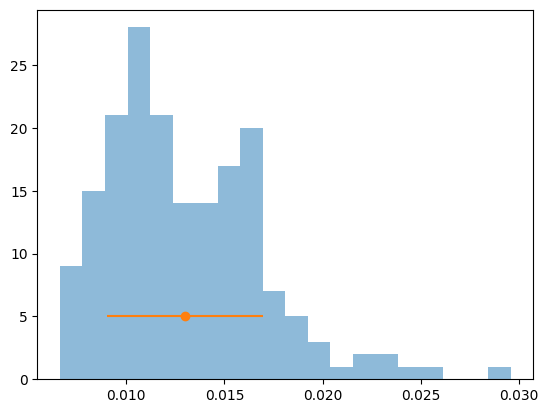

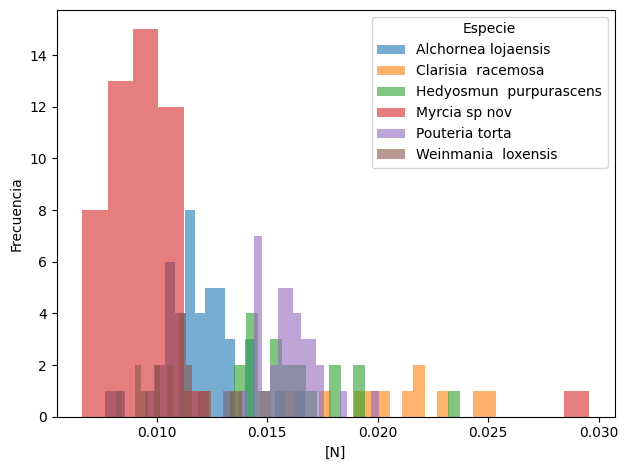

In [ ]:
import matplotlib.pyplot as plt
### Variables fisiologicas ###
## histogramas ##

import numpy as np

# Calcular la media y la desviación estándar
mean = data[var].mean()
std = data[var].std()
 
# Trazar histograma con barras de error
plt.hist(data[var], bins=20, alpha=0.5)
plt.errorbar(mean, 5, xerr=std, fmt='o')
plt.show()


for name, grupo in data.groupby("name"):
    plt.hist(grupo[var], bins=20, alpha=0.6, label=name)

plt.xlabel(var)
plt.ylabel("Frecuencia")
plt.legend(title="Especie")  # aquí se activa la leyenda
plt.tight_layout()
plt.show()


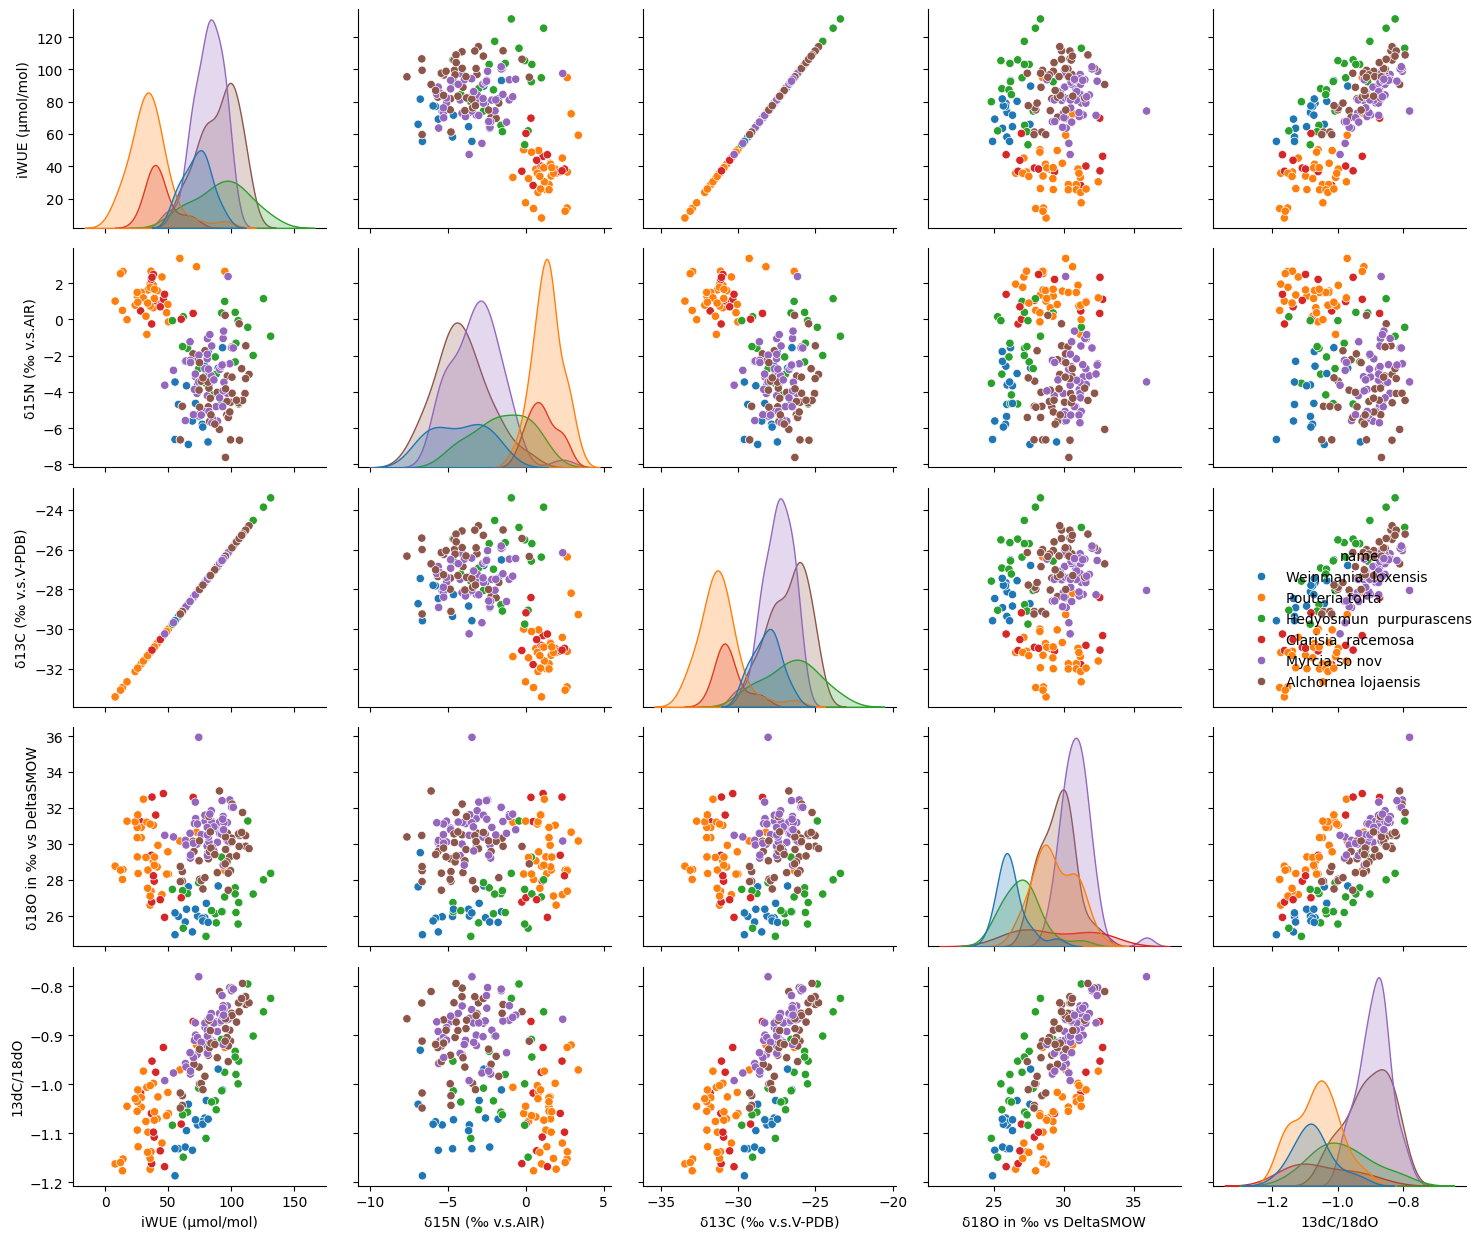

In [ ]:
columnas = [vp1,vp2,vp3,vp4,vp7]

sns.pairplot(
    data=data,
    vars=columnas, 
    hue = "name",  # columnas numéricas que quieres graficar
    #kind = "reg"
)
plt.tight_layout()
plt.show()



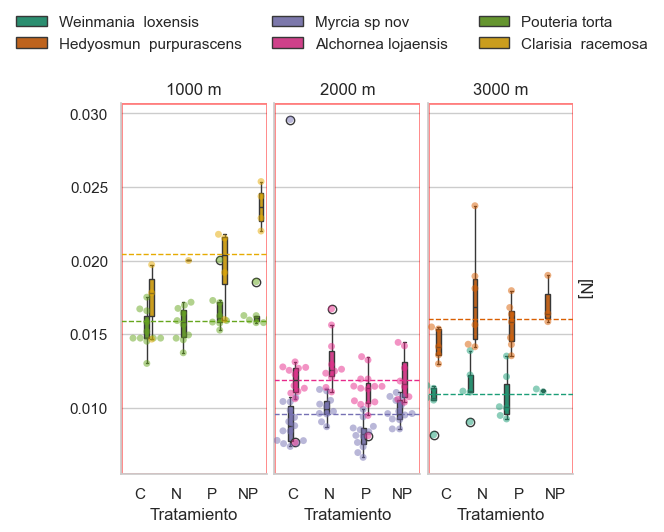

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as patches

# Simulación: tu código de melt y orden ya definido antes
df_long = pd.melt(
    data,
    id_vars=["name", "Sub"],
    value_vars=[var],
    var_name="variable",
    value_name="valor"
)

# Orden de tratamiento y especies
orden = ["C", "N", "P", "NP"]
orden_sp = ["Weinmania  loxensis","Hedyosmun  purpurascens",
            "Myrcia sp nov","Alchornea lojaensis",
            "Pouteria torta","Clarisia  racemosa"]

df_long["Sub"] = pd.Categorical(df_long["Sub"], categories=orden, ordered=True)
df_long["name"] = pd.Categorical(df_long["name"], categories=orden_sp, ordered=True)

# Asignar altitudes según el orden de especies
altitud_map = {
    "Weinmania  loxensis": "3000",
    "Hedyosmun  purpurascens": "3000",
    "Myrcia sp nov": "2000",
    "Alchornea lojaensis": "2000",
    "Pouteria torta": "1000",
    "Clarisia  racemosa": "1000"
}
df_long["altitud"] = df_long["name"].map(altitud_map)

# Colores fijos por especie
palette_species = {
    "Weinmania  loxensis": "#1b9e77",
    "Hedyosmun  purpurascens": "#d95f02",
    "Myrcia sp nov": "#7570b3",
    "Alchornea lojaensis": "#e7298a",
    "Pouteria torta": "#66a61e",
    "Clarisia  racemosa": "#e6ab02"
}

# Estilo
sns.set(style="whitegrid")

# Figura tamaño A4 reducido
figsize_a4 = (5.27, 5.69)

# Forzar el orden correcto de las altitudes
orden_alt = ["1000", "2000", "3000"]
df_long["altitud"] = pd.Categorical(df_long["altitud"], categories=orden_alt, ordered=True)

g = sns.FacetGrid(
    df_long,
    row="variable",
    col="altitud",
    sharey=True,
    height=3,
    aspect=1,
    margin_titles=True
)

# Boxplot por especie
g.map_dataframe(
    sns.boxplot,
    x="Sub", y="valor", hue="name",
    linewidth=1, palette=palette_species, dodge=True
)

# Swarmplot con mismo color
g.map_dataframe(
    sns.swarmplot,
    x="Sub", y="valor", hue="name",
    palette=palette_species, alpha=0.5, dodge=True
)

# Línea media por especie
for ax, (_, subdata) in zip(g.axes.flat, g.facet_data()):
    if subdata is None or subdata.empty:
        continue
    for sp in subdata["name"].unique():
        mean_val = subdata[subdata["name"] == sp]["valor"].mean()
        ax.axhline(
            y=mean_val,
            color=palette_species[sp],
            linestyle="--",
            linewidth=1
        )

# Etiquetas
g.set_axis_labels("Tratamiento", "")
g.set_titles(row_template="{row_name}", col_template="{col_name} m")

# Ajustar figura
g.fig.set_size_inches(figsize_a4)
g.fig.subplots_adjust(wspace=0.05, hspace=0.3)

# Leyenda única
handles, labels = g.axes[0][0].get_legend_handles_labels()
g.fig.legend(
    handles[:len(orden_sp)], labels[:len(orden_sp)],
    loc='upper center', bbox_to_anchor=(0.5, 1.05),
    ncol=3, frameon=False
)

# --- Dibujar cajas de altitud ---
# Como ahora el orden es fijo, podemos agrupar fácilmente
altitud_groups = {
    "1000 m": [0],
    "2000 m": [1],
    "3000 m": [2]
}

for alt_label, indices in altitud_groups.items():
    for idx in indices:
        ax = g.axes[0][idx]
        ax.add_patch(
            patches.Rectangle(
                (-0.5, ax.get_ylim()[0]),
                len(orden),
                ax.get_ylim()[1] - ax.get_ylim()[0],
                fill=False, lw=2, edgecolor="red", alpha=0.5
            )
        )

plt.show()


In [ ]:
%run kruskal_por_especie_y_tratamiento.py

kruskal_por_especie_y_tratamiento(data, variable=var)


Comparacion entre tratamientos
[N]

TEST KRUSKALL

Especie: Weinmania  loxensis
H = 1.094, p = 0.7786, df = 3

TEST ANOVA DE UNA VIA

Especie: Weinmania  loxensis
F-statistic: 0.4101571617863317
P-value: 0.7482147437173188
Comparacion entre tratamientos
[N]

TEST KRUSKALL

Especie: Pouteria torta
H = 5.053, p = 0.1680, df = 3

TEST ANOVA DE UNA VIA

Especie: Pouteria torta
F-statistic: 2.3411237620732392
P-value: 0.09182081167148966
Comparacion entre tratamientos
[N]

TEST KRUSKALL

Especie: Hedyosmun  purpurascens
H = 6.598, p = 0.0859, df = 3

TEST ANOVA DE UNA VIA

Especie: Hedyosmun  purpurascens
F-statistic: 1.9730033529076536
P-value: 0.15631678070321176
Comparacion entre tratamientos
[N]

TEST KRUSKALL

Especie: Clarisia  racemosa
H = 8.250, p = 0.0411, df = 3

TEST ANOVA DE UNA VIA

Especie: Clarisia  racemosa
F-statistic: 4.627266928037997
P-value: 0.03695090781546479
Comparacion entre tratamientos
[N]

TEST KRUSKALL

Especie: Myrcia sp nov
H = 16.094, p = 0.0011, df = 3

TEST

[{'especie': 'Weinmania  loxensis',
  'H': 1.093567251461991,
  'p': 0.7786271973893396,
  'df': 3},
 {'especie': 'Pouteria torta',
  'H': 5.052893626991559,
  'p': 0.16796473379047813,
  'df': 3},
 {'especie': 'Hedyosmun  purpurascens',
  'H': 6.598392084106365,
  'p': 0.08586188993755865,
  'df': 3},
 {'especie': 'Clarisia  racemosa',
  'H': 8.25,
  'p': 0.041117871391622145,
  'df': 3},
 {'especie': 'Myrcia sp nov',
  'H': 16.093804485948155,
  'p': 0.0010848569305658214,
  'df': 3},
 {'especie': 'Alchornea lojaensis',
  'H': 7.573670685906313,
  'p': 0.0556954474997105,
  'df': 3}]

In [ ]:
from scipy.stats import f_oneway
df = data
especie = "Alchornea lojaensis"
variable = var
sub_df = df[df['name'] == especie] #filtra por especie
sub_df['Sub'].unique() #array(['C', 'N', 'P', 'NP'], dtype=object)
        # Crear lista de valores por tratamiento (ignorando NaNs)
C = sub_df[sub_df['Sub'] =="C"][variable].dropna()
N = sub_df[sub_df['Sub'] =="N"][variable].dropna()
P = sub_df[sub_df['Sub'] =="P"][variable].dropna()
NP = sub_df[sub_df['Sub'] =="NP"][variable].dropna()

f_statistic, p_value = f_oneway(C,N,P,NP)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

F-statistic: 3.610102421442305
P-value: 0.02106147890474067


In [ ]:
data["Plot"] = data["Plot"].astype(str)
data["TreeID"] = data["TreeID"].astype(str)
data["Sub"] = data["Sub"].astype(str)

data_numericas = data.select_dtypes(include=['number'])

respuesta = [vp1,vp2,vp3,vp4,vp5,vp7]
morfo =  [vf1,vf2,vf3,vf4,vf5,vf6,vf7]
coef = data_numericas.corr(method="pearson")


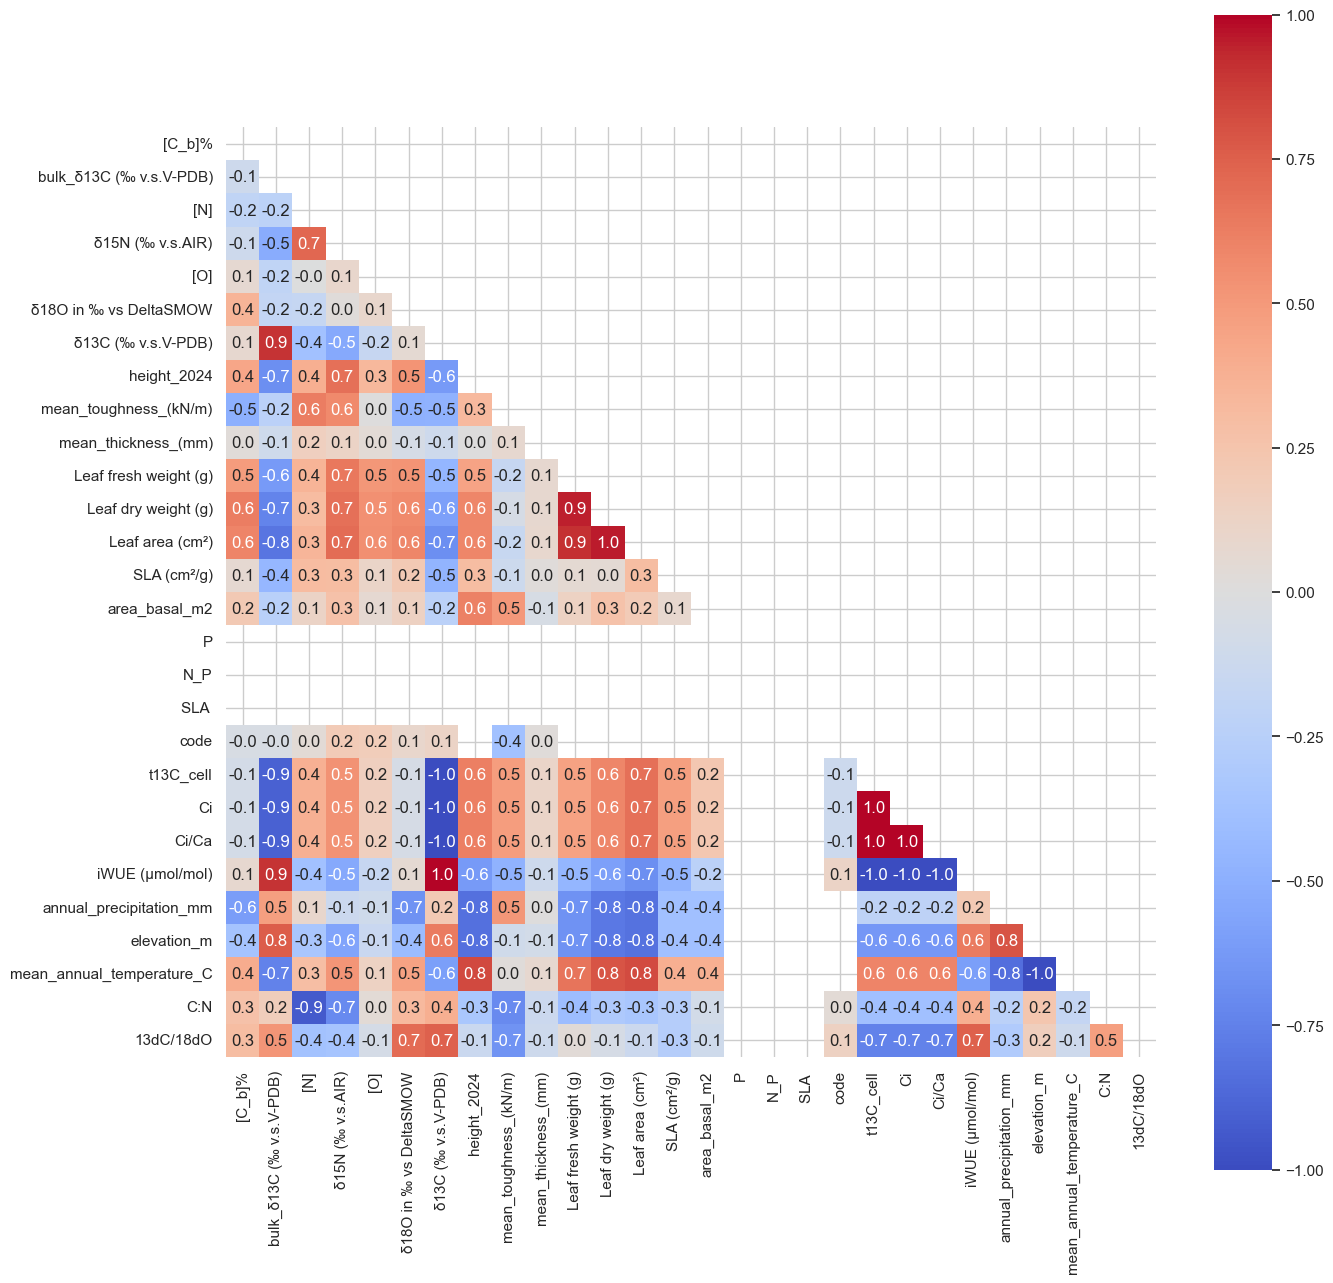

In [ ]:
# Supongamos que 'coef' es tu DataFrame de correlación o coeficientes
import numpy as np
mask = np.triu(np.ones_like(coef, dtype=bool))  # Triángulo superior
plt.figure(figsize=(15, 15))
sns.heatmap(coef, mask=mask, annot=True, fmt=".1f", cmap="coolwarm", square=True)
plt.show()

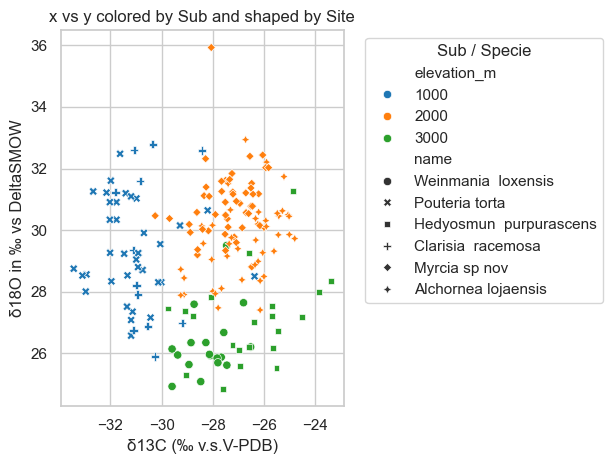

In [ ]:
# Example assuming SLA is your DataFrame
sns.scatterplot(
    data=data,
    x=vp3,
    y=vp4,
    hue="elevation_m",    # color by Sub
    style="name", # marker shape by Site
    palette="tab10"  # optional: set color palette
)

plt.title("x vs y colored by Sub and shaped by Site")
plt.legend(title="Sub / Specie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

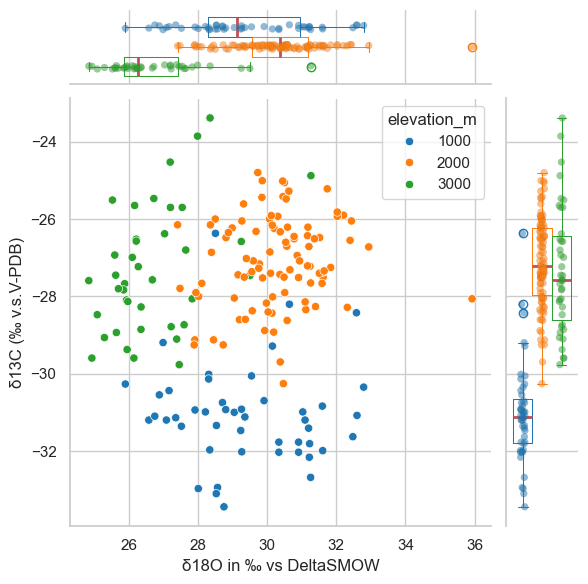

In [ ]:
g = sns.JointGrid(data=data, x=vp4, y=vp3, hue="elevation_m", palette="tab10")
g.plot_joint(sns.scatterplot)
g.plot_marginals(sns.stripplot, hue="elevation_m", linewidth=0.1,dodge=True,alpha=.5)
g.plot_marginals(sns.boxplot, hue="elevation_m",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2})


| **Pattern**                          | **Interpretation**                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------- |
| Both δ¹³C and δ¹⁸O increase          | Likely due to **reduced stomatal conductance** → both iWUE and leaf water δ¹⁸O increase.    |
| δ¹³C increases but δ¹⁸O does not     | Possibly due to **increased photosynthesis**, not stomatal closure.                         |
| δ¹³C does not increase but δ¹⁸O does | Could indicate **stomatal closure**, but photosynthesis also dropped → no iWUE gain.        |
| No correlation                       | Suggests other processes dominate (e.g., environmental noise, post-photosynthetic effects). |


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib import pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.factorplots import interaction_plot
from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
qqplot(data[v],line='s') #ajustar variables
plt.show()


NameError: name 'v' is not defined

Normality: HELP: Does it look normal?
small sample levene test


In [ ]:
levene(
     data[v6][data['name'] == 'Weinmania loxensis	'],
     data[v6][data['name'] == 'Pouteriatorta'],
     data[v6][data['name'] == 'Hedyosmum purpurascens'],
     data[v6][data['name'] == 'Clarisia racemosa'], center='mean')

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_17248\2616922269.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  levene(


LeveneResult(statistic=nan, pvalue=nan)

In [ ]:
data["iWUE"] = data["iWUE (μmol/mol)"]
modelo = ols('iWUE ~ C(name) + C(Sub) + C(name):C(Sub)', data=data).fit()
anova_result = sm.stats.anova_lm(modelo, type=3)
anova_result

PatsyError: Error evaluating factor: TypeError: 'Series' object is not callable
    iWUE ~ C(name) + C(Sub) + C(name):C(Sub)
                     ^^^^^^